# Neural Networks Assignment, 2025 A2 <ignore>
## Overview
In this assessment, you will be asked to carry out three tasks. The first task involves building and training a simple CNN-based classifier for the Fashion MNIST dataset, and demonstrating the effectiveness of a technique to improve gradient flow. The second task involves building and training an unconditional GAN to generate images that look like those in the Fashion MNIST dataset, and using the discriminator to investigate the quality of the generated images. The third task involves augmenting the GAN to improve the generated images in some way.

## Instructions
### Code and Markdown cells
All of your report, including code and Markdown/text, ***must*** be written up in ***this*** notebook. Please make sure you change the title of this file so that XXXXXX is replaced by your candidate number. You can use code cells, where provided, to write code to implement, train, test, and analyse your NNs, as well as to generate figures to plot data and the results of your experiments. If you wish to add more code cells, you may do so immediately after the code cells that have been provided, but do not add any code cells anywhere else in this file. You must use the Markdown/text cells that are provided for writing the three report sections, one for each Task. These Markdown cells have "*Replace this text with your report for Task X*" in italics. Please replace that text with your own text. So that we can mark your reports with greater consistency, please ***do not***:

* add any of your own Markdown cells.
* rearrange the sequence of cells in this notebook.
* delete any cells, including the ones explaining what you need to do.

### Plotting figures
All plots of data ***must*** be produced as output from a code cell. Any plots that have been imported as images, rather than being the output of a plot function (such as that provided by matplotlib) will not receive marks. This is to ensure that you did the work to produce that plot. All figures should have an accompanying caption that states the Figure number and a detailed description of what the figure shows (see the guidenace in the file ```useful_code_for_figures_equations.ipynb```). 

### Writing code
Where relevant in your written report, e.g. when describing your methods, indicate where in your code the methods are implemented, including  the cell and line numbers (if you use VSCode, these are visible in the bottom right corner of the window). You might say, for example, "_layers 1-4 used 3x3 convolutional filters with a stride of 1 and padding of 1 (cell 5, line 30)_".  Please provide verbose comments throughout your code so that it is easy for us to interpret what you are attempting to achieve. Long comments are useful at the beginning of a block of code. Short comments, e.g. to explain the purpose of a new variable, or one of several steps in some analyses, are useful on every few lines of code, if not on every line. Please do not use the code cells for writing verbose responses to subtasks, which should instead be written in the provided Markdown cells.

# TASK 1 <ignore>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# the 10 Fashion MNIST classes, in label order 0-9
CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# convert images to tensors and normalise using Fashion MNIST's channel mean/std
# normalisation shifts pixel values to be roughly zero-centred with std ~1,
# which makes gradient descent more stable
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.2860,), std=(0.3530,))
])

# download the dataset; torchvision caches it in ./data after the first run
full_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# split the 60,000-image training set 80/20 into train (48k) and validation (12k)
# seed=42 makes the split identical every time the notebook is run
n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = random_split(full_train, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

# batch size 64 — standard choice; shuffle=True on training to randomise example order each epoch
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")


Train: 48000  |  Val: 12000  |  Test: 10000


In [2]:
# 5-layer CNN classifier for Fashion MNIST
#
# Input: 1 x 28 x 28 greyscale image
# Output: 10 raw logits (one per class)
#
# 5 convolutional layers are used for feature extraction.
# Global Average Pooling (GAP) then collapses each feature map to a single value,
# avoiding the large flattened FC layer that would otherwise follow.
# A single Linear(512 -> 10) layer maps the pooled features to class logits.
#
# Layer | Type            | Operation                             | Output shape
# ------|-----------------|---------------------------------------|--------------------
#   1   | Conv(1->32)     | 3x3, pad=1 -> [BN] -> ReLU -> Pool   | 32 x 14 x 14
#   2   | Conv(32->64)    | 3x3, pad=1 -> [BN] -> ReLU -> Pool   | 64 x  7 x  7
#   3   | Conv(64->128)   | 3x3, pad=1 -> [BN] -> ReLU           | 128 x  7 x  7
#   4   | Conv(128->256)  | 3x3, pad=1 -> [BN] -> ReLU -> Pool   | 256 x  3 x  3
#   5   | Conv(256->512)  | 3x3, pad=1 -> [BN] -> ReLU           | 512 x  3 x  3
#        GAP (AdaptiveAvgPool2d(1))                               | 512
#        Dropout(0.3)                                             | 512
#        Linear(512 -> 10) — one logit per class                  | 10
#
# Pools are placed after layers 1, 2, and 4: 28 -> 14 -> 7 -> 3.
# Layers 3 and 5 have no pool, keeping spatial size to allow more feature learning.
# GAP averages each of the 512 feature maps over the 3x3 spatial region -> 512 values.
#
# use_bn flag: True enables BatchNorm after each conv (the gradient flow technique).
#              False keeps the same architecture without BatchNorm (baseline comparison).
# BatchNorm normalises each feature map across the mini-batch before the ReLU,
# stabilising gradient magnitudes during backprop (Ioffe & Szegedy, 2015).

class CNN(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        self.use_bn = use_bn

        # --- Layer 1: 1 -> 32 channels ---
        self.conv1 = nn.Conv2d(1,   32,  kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # --- Layer 2: 32 -> 64 channels ---
        self.conv2 = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # --- Layer 3: 64 -> 128 channels (no pool — keeps 7x7) ---
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # --- Layer 4: 128 -> 256 channels ---
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        # --- Layer 5: 256 -> 512 channels (no pool) ---
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)          # halves spatial dims: 28->14->7->3
        self.gap  = nn.AdaptiveAvgPool2d(1)     # global avg pool: collapses HxW to 1x1
        self.drop = nn.Dropout(0.3)             # regularisation before classifier
        self.fc   = nn.Linear(512, 10)          # one logit per class

    def forward(self, x):
        # Layer 1: low-level features (edges, gradients)
        x = self.conv1(x)
        if self.use_bn: x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)    # 1x28x28 -> 32x14x14

        # Layer 2: mid-level features (corners, textures)
        x = self.conv2(x)
        if self.use_bn: x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)    # 32x14x14 -> 64x7x7

        # Layer 3: deeper features, spatial size kept at 7x7
        x = self.conv3(x)
        if self.use_bn: x = self.bn3(x)
        x = F.relu(x)       # 64x7x7 -> 128x7x7

        # Layer 4: complex features (garment parts and silhouettes)
        x = self.conv4(x)
        if self.use_bn: x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x)    # 128x7x7 -> 256x3x3

        # Layer 5: highest-level features, spatial size kept at 3x3
        x = self.conv5(x)
        if self.use_bn: x = self.bn5(x)
        x = F.relu(x)       # 256x3x3 -> 512x3x3

        # Global Average Pooling: average each feature map over the 3x3 region
        x = self.gap(x)                  # [batch, 512, 3, 3] -> [batch, 512, 1, 1]
        x = x.view(x.size(0), -1)        # flatten -> [batch, 512]

        x = self.drop(x)
        x = self.fc(x)                   # [batch, 512] -> [batch, 10] logits
        return x


# sanity check: a blank 1x28x28 image should produce 10 output logits
dummy = torch.zeros(1, 1, 28, 28)
assert CNN(use_bn=True)(dummy).shape == (1, 10), "output shape is wrong"
print("Architecture check passed — output: (batch, 10)")
print(CNN(use_bn=True))


Architecture check passed — output: (batch, 10)
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0,

In [3]:
# Helper functions defined here so they are available for the LR experiment below
#
# train_one_epoch: one full pass through the training set.
#   model.train() enables Dropout and makes BatchNorm use batch statistics.
#
# evaluate: runs the model with no weight updates.
#   model.eval() disables Dropout and switches BatchNorm to its running statistics.
#   torch.no_grad() skips the computation graph to save memory.

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        optimizer.zero_grad()              # clear gradients from last step
        outputs = model(images)            # forward pass -> logits
        loss = criterion(outputs, labels)  # cross-entropy loss
        loss.backward()                    # backprop: compute gradients
        optimizer.step()                   # Adam weight update

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)   # class with highest logit
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return total_loss / total, correct / total



LR = 0.0001
  epoch 1/5  val acc: 88.4%
  epoch 2/5  val acc: 90.0%
  epoch 3/5  val acc: 91.1%
  epoch 4/5  val acc: 91.1%
  epoch 5/5  val acc: 91.0%

LR = 0.0005
  epoch 1/5  val acc: 88.6%
  epoch 2/5  val acc: 90.6%
  epoch 3/5  val acc: 91.5%
  epoch 4/5  val acc: 92.0%
  epoch 5/5  val acc: 91.6%

LR = 0.001
  epoch 1/5  val acc: 88.9%
  epoch 2/5  val acc: 89.5%
  epoch 3/5  val acc: 90.6%
  epoch 4/5  val acc: 91.2%
  epoch 5/5  val acc: 91.7%

LR = 0.005
  epoch 1/5  val acc: 88.5%
  epoch 2/5  val acc: 89.6%
  epoch 3/5  val acc: 90.0%
  epoch 4/5  val acc: 91.4%
  epoch 5/5  val acc: 92.0%

LR = 0.01
  epoch 1/5  val acc: 88.7%
  epoch 2/5  val acc: 87.7%
  epoch 3/5  val acc: 90.4%
  epoch 4/5  val acc: 90.8%
  epoch 5/5  val acc: 91.0%

Best LR: 0.005  (val acc = 92.0% at epoch 5)


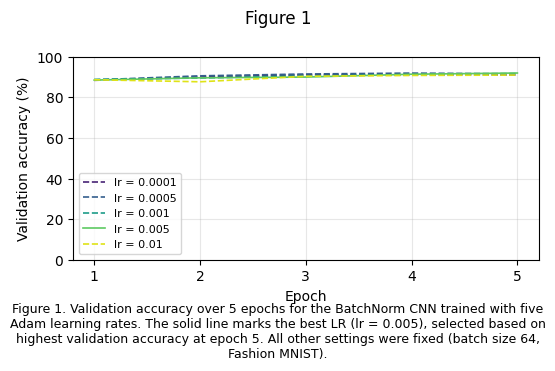

In [4]:
# Learning rate search — Figure 1
# Test 5 candidate LRs for 5 epochs each using the BatchNorm CNN.
# 5 epochs is enough to see which LRs converge quickly vs stall or overshoot.
# Adam is used throughout; all other settings are fixed.
# The LR with the highest validation accuracy at epoch 5 is used for the main training.

LEARNING_RATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
LR_EPOCHS = 5   # short pilot — faster on CPU, still enough to rank LRs

lr_val_acc_histories = {}
criterion = nn.CrossEntropyLoss()

for lr in LEARNING_RATES:
    model_lr = CNN(use_bn=True)   # fresh model for each candidate LR
    opt_lr   = optim.Adam(model_lr.parameters(), lr=lr)
    val_accs = []

    print(f"\nLR = {lr}")
    for epoch in range(1, LR_EPOCHS + 1):
        train_one_epoch(model_lr, train_loader, criterion, opt_lr)
        _, vl_acc = evaluate(model_lr, val_loader, criterion)
        val_accs.append(vl_acc * 100)
        print(f"  epoch {epoch}/{LR_EPOCHS}  val acc: {vl_acc*100:.1f}%")

    lr_val_acc_histories[lr] = val_accs

# select the best LR based on final epoch val accuracy
BEST_LR = max(LEARNING_RATES, key=lambda r: lr_val_acc_histories[r][-1])
print(f"\nBest LR: {BEST_LR}  (val acc = {lr_val_acc_histories[BEST_LR][-1]:.1f}% at epoch {LR_EPOCHS})")

# Figure 1: LR search — val accuracy curves for all 5 candidate learning rates
figWidth  = 14.
figHeight = 8.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 1')

colors = plt.cm.viridis([0.1, 0.3, 0.55, 0.75, 0.95])
for (lr, accs), col in zip(lr_val_acc_histories.items(), colors):
    ax.plot(range(1, LR_EPOCHS + 1), accs, linewidth=1.2, color=col,
            label=f'lr = {lr}',
            linestyle='-' if lr == BEST_LR else '--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy (%)')
ax.set_ylim([0, 100])
ax.xaxis.set_ticks(range(1, LR_EPOCHS + 1))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

txt = (f"Figure 1. Validation accuracy over {LR_EPOCHS} epochs for the BatchNorm CNN "
       f"trained with five Adam learning rates. The solid line marks the best LR "
       f"(lr = {BEST_LR}), selected based on highest validation accuracy at epoch {LR_EPOCHS}. "
       f"All other settings were fixed (batch size 64, Fashion MNIST).")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig1_lr_search.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# train_model wraps train_one_epoch and evaluate to run a complete training run,
# recording loss and accuracy each epoch so we can plot learning curves afterwards.
# A fresh CNN is created each call so both variants start independently.

def train_model(use_bn, n_epochs=15, lr=1e-3):
    model     = CNN(use_bn=use_bn)     # fresh model, no device needed (CPU by default)
    criterion = nn.CrossEntropyLoss()  # expects raw logits, applies log-softmax internally
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    name = "BatchNorm" if use_bn else "Baseline (no BN)"
    print(f"\nTraining: {name}  lr={lr}")

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f"  epoch {epoch:2d}/{n_epochs}  "
              f"train {tr_loss:.4f} / {tr_acc*100:.1f}%  |  "
              f"val {vl_loss:.4f} / {vl_acc*100:.1f}%")

    return model, history


# train both variants for 15 epochs using the best LR found in the search above
N_EPOCHS = 15
model_baseline, hist_baseline = train_model(use_bn=False, n_epochs=N_EPOCHS, lr=BEST_LR)
model_bn,       hist_bn       = train_model(use_bn=True,  n_epochs=N_EPOCHS, lr=BEST_LR)



Training: Baseline (no BN)  lr=0.005
  epoch  1/15  train 0.6761 / 74.2%  |  val 0.4384 / 83.8%
  epoch  2/15  train 0.4045 / 85.0%  |  val 0.3754 / 86.1%
  epoch  3/15  train 0.3636 / 86.4%  |  val 0.3694 / 86.9%
  epoch  4/15  train 0.3416 / 87.1%  |  val 0.3453 / 87.9%
  epoch  5/15  train 0.3285 / 87.8%  |  val 0.3347 / 87.8%
  epoch  6/15  train 0.3149 / 88.2%  |  val 0.3853 / 86.0%
  epoch  7/15  train 0.3076 / 88.4%  |  val 0.3349 / 87.0%
  epoch  8/15  train 0.2944 / 89.0%  |  val 0.3341 / 88.4%
  epoch  9/15  train 0.2904 / 89.0%  |  val 0.3339 / 87.7%
  epoch 10/15  train 0.2873 / 89.2%  |  val 0.3225 / 88.3%
  epoch 11/15  train 0.2779 / 89.5%  |  val 0.3395 / 87.5%
  epoch 12/15  train 0.2754 / 89.5%  |  val 0.3215 / 88.5%
  epoch 13/15  train 0.2652 / 89.8%  |  val 0.3330 / 88.2%
  epoch 14/15  train 0.2727 / 89.8%  |  val 0.3290 / 89.0%
  epoch 15/15  train 0.2646 / 90.1%  |  val 0.3192 / 89.0%

Training: BatchNorm  lr=0.005
  epoch  1/15  train 0.4354 / 84.0%  |  val 0.

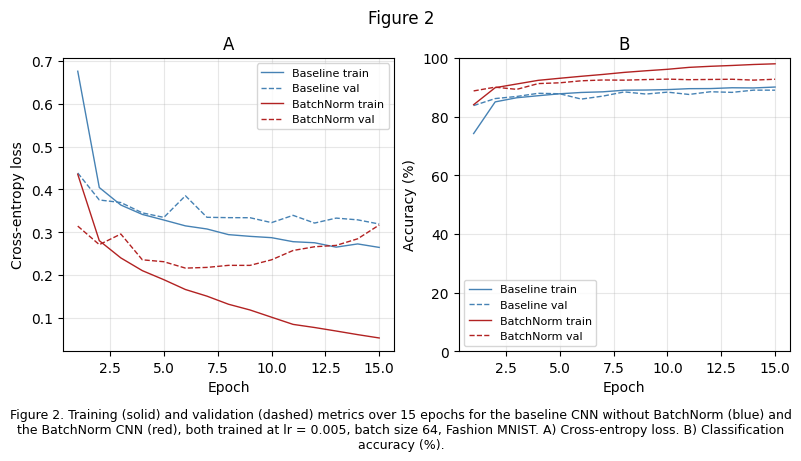

In [6]:
# Figure 2: learning curves — BatchNorm ablation
# Plotting both models together makes it easy to see the effect of BatchNorm
# on convergence speed and final accuracy.
# Solid = training set, dashed = validation set.

epochs = range(1, N_EPOCHS + 1)

figWidth  = 20.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
                         figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 2')

# panel A: cross-entropy loss
axs[0].set_title('A')
axs[0].plot(epochs, hist_baseline['train_loss'], color='steelblue', linestyle='-',  linewidth=1.0, label='Baseline train')
axs[0].plot(epochs, hist_baseline['val_loss'],   color='steelblue', linestyle='--', linewidth=1.0, label='Baseline val')
axs[0].plot(epochs, hist_bn['train_loss'],       color='firebrick', linestyle='-',  linewidth=1.0, label='BatchNorm train')
axs[0].plot(epochs, hist_bn['val_loss'],         color='firebrick', linestyle='--', linewidth=1.0, label='BatchNorm val')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Cross-entropy loss')
axs[0].legend(fontsize=8)
axs[0].grid(True, alpha=0.3)

# panel B: classification accuracy
axs[1].set_title('B')
axs[1].plot(epochs, [v*100 for v in hist_baseline['train_acc']], color='steelblue', linestyle='-',  linewidth=1.0, label='Baseline train')
axs[1].plot(epochs, [v*100 for v in hist_baseline['val_acc']],   color='steelblue', linestyle='--', linewidth=1.0, label='Baseline val')
axs[1].plot(epochs, [v*100 for v in hist_bn['train_acc']],       color='firebrick', linestyle='-',  linewidth=1.0, label='BatchNorm train')
axs[1].plot(epochs, [v*100 for v in hist_bn['val_acc']],         color='firebrick', linestyle='--', linewidth=1.0, label='BatchNorm val')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_ylim([0, 100])
axs[1].legend(fontsize=8)
axs[1].grid(True, alpha=0.3)

txt = (f"Figure 2. Training (solid) and validation (dashed) metrics over {N_EPOCHS} epochs "
       f"for the baseline CNN without BatchNorm (blue) and the BatchNorm CNN (red), "
       f"both trained at lr = {BEST_LR}, batch size 64, Fashion MNIST. "
       f"A) Cross-entropy loss. B) Classification accuracy (%).")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.savefig('fig2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Test-set results:
  Baseline CNN  — loss: 0.3283   accuracy: 88.30%
  BatchNorm CNN — loss: 0.3472   accuracy: 92.09%

Per-class test accuracy (BatchNorm CNN):
  T-shirt/top    : 88.8%
  Trouser        : 97.5%
  Pullover       : 90.0%
  Dress          : 93.3%
  Coat           : 87.2%
  Sandal         : 97.9%
  Shirt          : 76.9%
  Sneaker        : 99.5%
  Bag            : 99.0%
  Ankle boot     : 90.8%


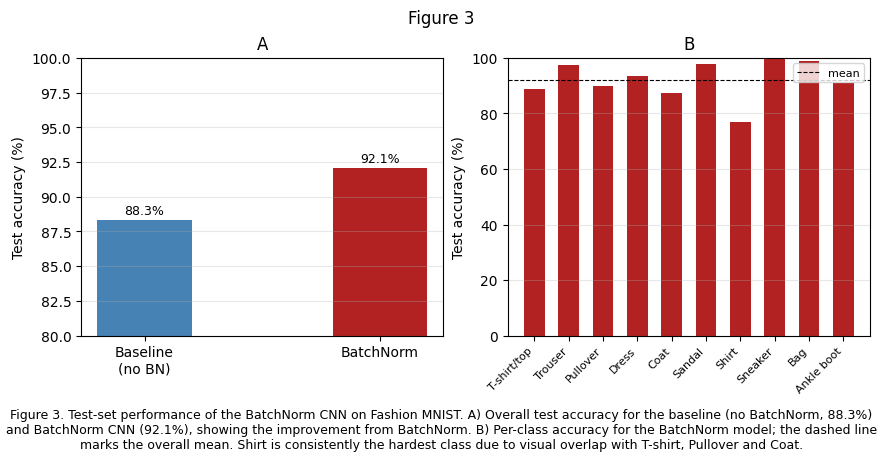

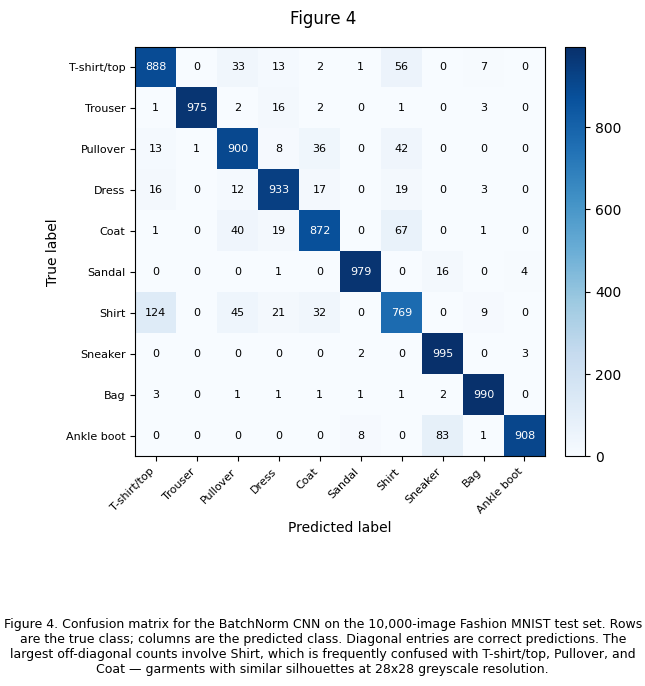

In [7]:
# Evaluate both models on the held-out test set (10,000 images never seen during training).
# The test set gives an unbiased measure of how the model performs on new data.

criterion = nn.CrossEntropyLoss()

test_loss_bl, test_acc_bl = evaluate(model_baseline, test_loader, criterion)
test_loss_bn, test_acc_bn = evaluate(model_bn,       test_loader, criterion)

print("Test-set results:")
print(f"  Baseline CNN  — loss: {test_loss_bl:.4f}   accuracy: {test_acc_bl*100:.2f}%")
print(f"  BatchNorm CNN — loss: {test_loss_bn:.4f}   accuracy: {test_acc_bn*100:.2f}%")

# --- per-class accuracy for the BatchNorm model ---
# also collect all predictions for the confusion matrix below
correct_per_class = {c: 0 for c in CLASSES}
total_per_class   = {c: 0 for c in CLASSES}
all_preds, all_labels_list = [], []

model_bn.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_bn(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())        # no .cpu() needed — already on CPU
        all_labels_list.extend(labels.numpy())

        for lbl, pred in zip(labels, predicted):
            cls = CLASSES[lbl.item()]
            total_per_class[cls] += 1
            if lbl == pred:
                correct_per_class[cls] += 1

per_class_acc = [100 * correct_per_class[c] / total_per_class[c] for c in CLASSES]

print("\nPer-class test accuracy (BatchNorm CNN):")
for cls, acc in zip(CLASSES, per_class_acc):
    print(f"  {cls:15s}: {acc:.1f}%")

# -----------------------------------------------------------------------
# Figure 3: BatchNorm ablation (overall) + per-class test accuracy
# Panel A: overall test accuracy comparison — baseline vs BatchNorm
# Panel B: per-class accuracy for the BatchNorm model
# -----------------------------------------------------------------------
figWidth  = 22.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
                         figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 3')

# panel A: BatchNorm ablation — side-by-side overall accuracy
axs[0].set_title('A')
bars = axs[0].bar(['Baseline\n(no BN)', 'BatchNorm'],
                   [test_acc_bl * 100, test_acc_bn * 100],
                   color=['steelblue', 'firebrick'], width=0.4)
axs[0].set_ylabel('Test accuracy (%)')
axs[0].set_ylim([80, 100])   # zoom in so the difference is visible
for bar, val in zip(bars, [test_acc_bl * 100, test_acc_bn * 100]):
    axs[0].text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axs[0].grid(True, axis='y', alpha=0.3)

# panel B: per-class accuracy for the BatchNorm CNN
axs[1].set_title('B')
x = np.arange(len(CLASSES))
axs[1].bar(x, per_class_acc, color='firebrick', width=0.6)
axs[1].set_xticks(x)
axs[1].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
axs[1].set_ylabel('Test accuracy (%)')
axs[1].set_ylim([0, 100])
axs[1].axhline(test_acc_bn * 100, color='black', linestyle='--', linewidth=0.8, label='mean')
axs[1].legend(fontsize=8)
axs[1].grid(True, axis='y', alpha=0.3)

txt = (f"Figure 3. Test-set performance of the BatchNorm CNN on Fashion MNIST. "
       f"A) Overall test accuracy for the baseline (no BatchNorm, {test_acc_bl*100:.1f}%) "
       f"and BatchNorm CNN ({test_acc_bn*100:.1f}%), showing the improvement from BatchNorm. "
       f"B) Per-class accuracy for the BatchNorm model; the dashed line marks the overall mean. "
       f"Shirt is consistently the hardest class due to visual overlap with T-shirt, Pullover and Coat.")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.savefig('fig3_ablation_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------
# Figure 4: Confusion matrix
# Rows = true class, columns = predicted class.
# Diagonal entries are correct; off-diagonal entries show confusions.
# -----------------------------------------------------------------------
cm = confusion_matrix(all_labels_list, all_preds)

figWidth  = 16.
figHeight = 14.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 4')

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# annotate each cell with its count; white text on dark cells for readability
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')

tick_marks = np.arange(len(CLASSES))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel('Predicted label')   # columns = model's guess
ax.set_ylabel('True label')        # rows    = ground truth

txt = ("Figure 4. Confusion matrix for the BatchNorm CNN on the 10,000-image Fashion MNIST test set. "
       "Rows are the true class; columns are the predicted class. "
       "Diagonal entries are correct predictions. "
       "The largest off-diagonal counts involve Shirt, which is frequently confused with "
       "T-shirt/top, Pullover, and Coat — garments with similar silhouettes at 28x28 greyscale resolution.")
plt.figtext(0.5, -0.22, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


# TASK 2 <ignore>

*Replace this text with your report for Task 2*

In [ ]:
###
### Use this code cell for Task 2. You may create code cells immediately 
### after this one if you need to.
###

# TASK 3 <ignore>

*Replace this text with your report for Task 3*

In [ ]:
###
### Use this code cell for Task 3. You may create code cells immediately 
### after this one if you need to.
###

## References <ignore>

*Replace this text with full references for any published articles that you cite in the report*